# Stock Current-Day Deliverable Volume Prediction System

## 1. Import Libraries

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [2]:
df = pd.read_csv("data/ADANIPORTS.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


## 3. Dataset Information

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (3322, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                3322 non-null   object 
 1   Symbol              3322 non-null   object 
 2   Series              3322 non-null   object 
 3   Prev Close          3322 non-null   float64
 4   Open                3322 non-null   float64
 5   High                3322 non-null   float64
 6   Low                 3322 non-null   float64
 7   Last                3322 non-null   float64
 8   Close               3322 non-null   float64
 9   VWAP                3322 non-null   float64
 10  Volume              3322 non-null   int64  
 11  Turnover            3322 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  3322 non-null   int64  
 14  %Deliverble         3322 non-null   float64
dtypes: float64(10), int64(2), object(3)
m

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3.322000e+03,3.322000e+03,2.456000e+03,3.322000e+03,3322.000000
mean,344.114314,344.763019,351.608007,337.531969,344.239539,344.201626,344.853182,2.954564e+06,1.070144e+14,4.492259e+04,1.207441e+06,0.445899
std,192.936882,193.619992,198.617808,188.676614,193.187813,193.045886,193.841305,4.104227e+06,2.625564e+14,5.023124e+04,1.398640e+06,0.160496
min,108.000000,108.000000,110.450000,105.650000,108.000000,108.000000,108.340000,1.236600e+04,2.415857e+11,3.660000e+02,5.383000e+03,0.067000
25%,164.312500,164.850000,168.000000,161.600000,164.075000,164.312500,164.855000,7.493682e+05,1.817650e+13,2.083200e+04,3.212005e+05,0.332900
50%,324.700000,325.750000,331.275000,319.850000,325.000000,324.700000,325.765000,2.007292e+06,5.836041e+13,3.588150e+04,8.132775e+05,0.445650
75%,400.912500,401.000000,407.187500,395.000000,400.912500,400.912500,400.607500,3.636883e+06,1.158526e+14,5.336875e+04,1.605528e+06,0.555850
max,1307.450000,1310.250000,1324.000000,1270.000000,1308.000000,1307.450000,1302.150000,9.771788e+07,8.160988e+15,1.205984e+06,2.241652e+07,0.979800


## 4. Missing Values

In [4]:
df.isnull().sum()

Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                866
Deliverable Volume      0
%Deliverble             0
dtype: int64

## 5. Date Conversion and Sorting

In [5]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


## 6. Exploratory Data Analysis

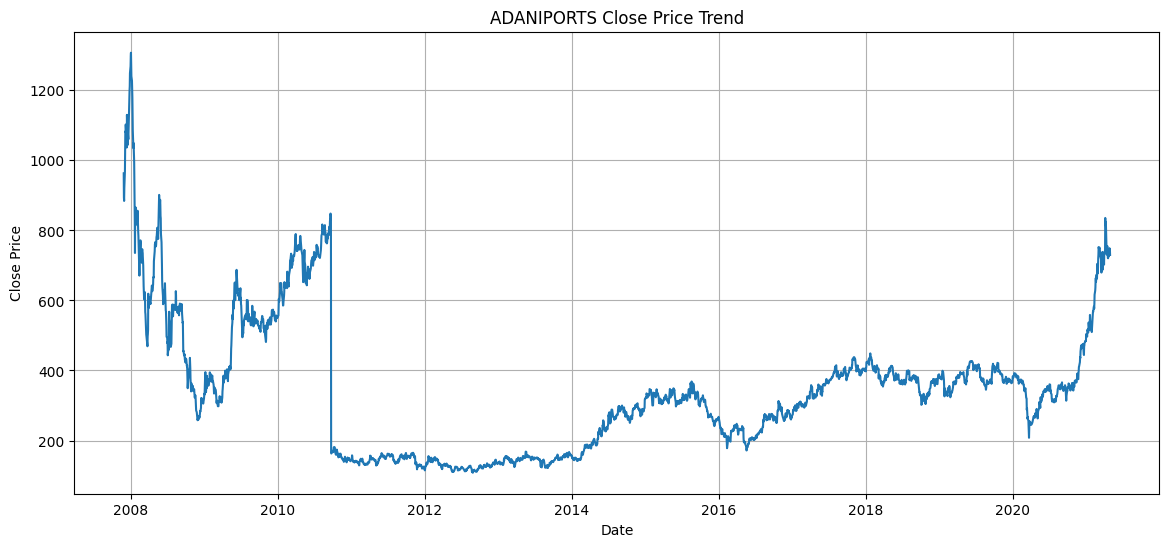

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("ADANIPORTS Close Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

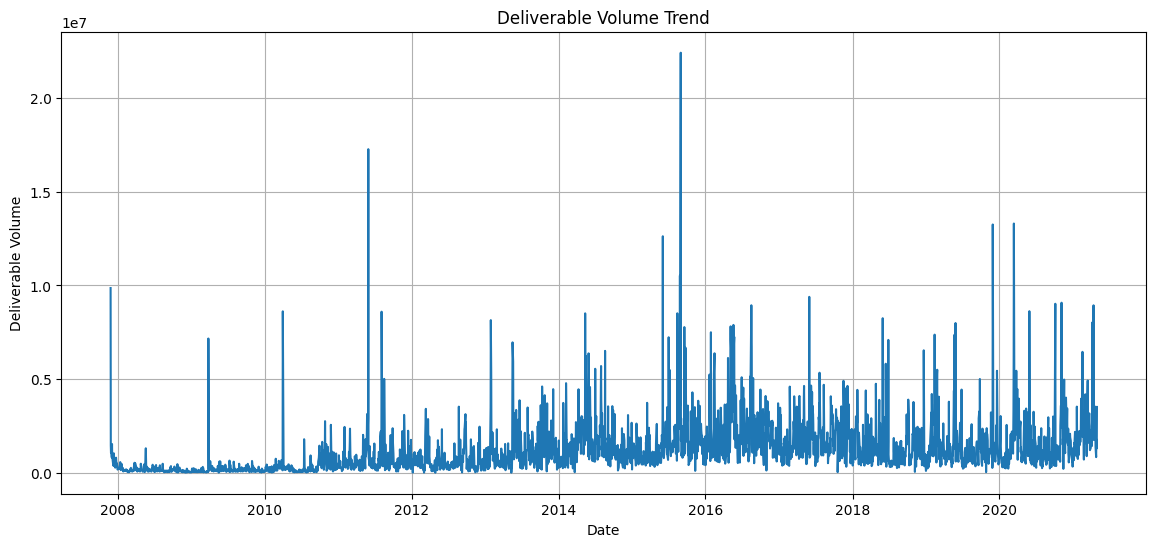

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Deliverable Volume"])
plt.title("Deliverable Volume Trend")
plt.xlabel("Date")
plt.ylabel("Deliverable Volume")
plt.grid(True)
plt.show()

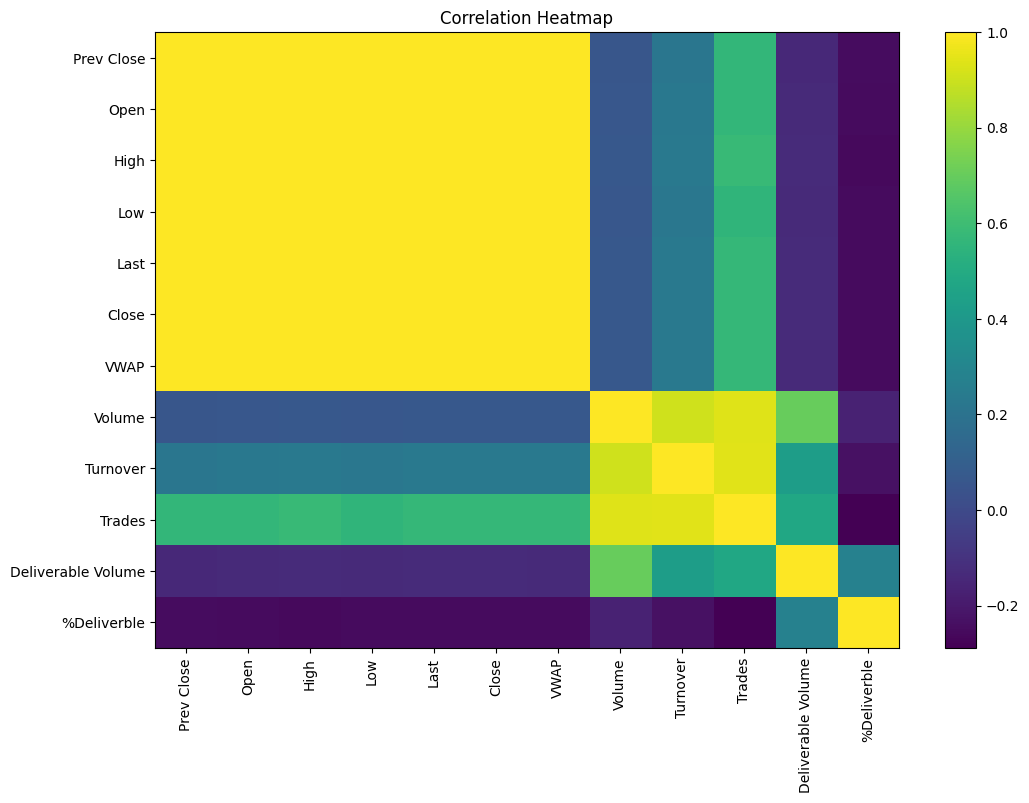

In [8]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.show()

## 7. Feature Selection

In [9]:
features = [
    "Prev Close", "Open", "High", "Low", "Last",
    "Close", "VWAP", "Volume", "Turnover"
]

target = "Deliverable Volume"

model_df = df[features + [target]].copy().dropna()
X = model_df[features]
y = model_df[target]
X.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover
0,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15
1,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14
2,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14
3,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14
4,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14


## 8. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 2657
Testing rows: 665


## 9. Model Training - Random Forest Regressor

In [11]:
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

## 10. Model Evaluation

In [12]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE: 350206.55
RMSE: 841158.53
R2 Score: 0.722


## 11. Actual vs Predicted Comparison

In [13]:
comparison_df = pd.DataFrame({
    "Actual Deliverable Volume": y_test.values,
    "Predicted Deliverable Volume": y_pred
})
comparison_df.head(20)

,Actual Deliverable Volume,Predicted Deliverable Volume
0,277511,226147.160
1,281078,193845.205
2,433124,435772.010
3,701228,646061.795
4,1862764,1426099.995
5,1455711,1244917.565
6,338505,315847.945
7,7891714,6201751.675
8,698568,2148802.420
9,2948800,2930333.540


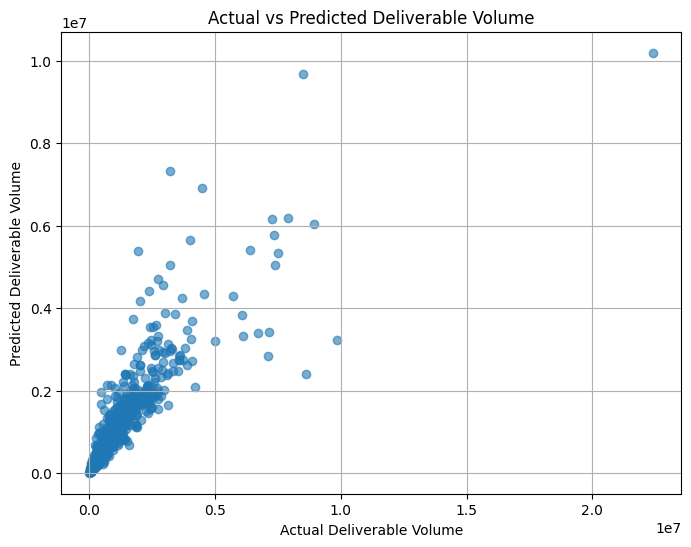

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Deliverable Volume")
plt.ylabel("Predicted Deliverable Volume")
plt.title("Actual vs Predicted Deliverable Volume")
plt.grid(True)
plt.show()

## 12. Feature Importance

In [15]:
importance_df = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_}).sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
7,Volume,0.747584
8,Turnover,0.041206
2,High,0.037683
1,Open,0.036839
0,Prev Close,0.034272
6,VWAP,0.031776
4,Last,0.023953
5,Close,0.023390
3,Low,0.023298


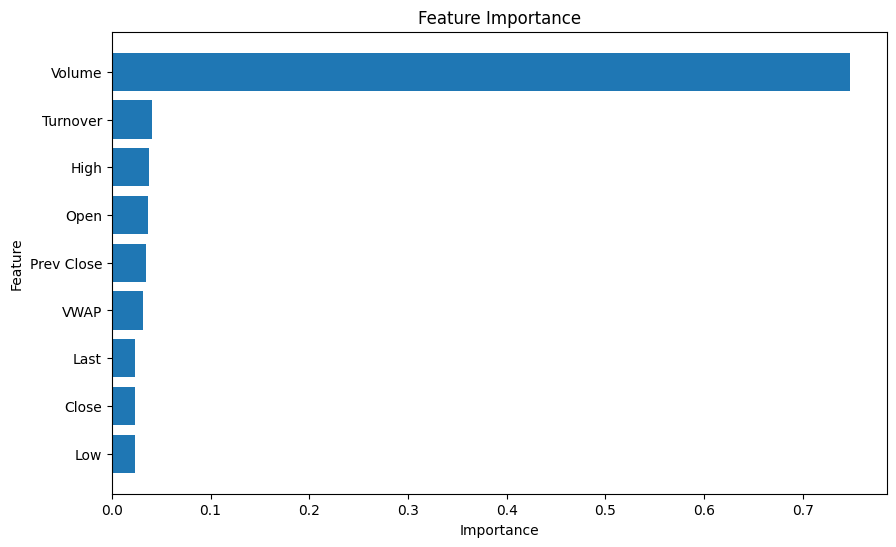

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 13. Save Model

In [17]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/stock_deliverable_model.joblib")
joblib.dump(features, "models/features.joblib")
metrics = {
    "Prediction Type": "Current-Day Deliverable Volume Prediction",
    "MAE": round(float(mae), 2),
    "RMSE": round(float(rmse), 2),
    "R2 Score": round(float(r2), 4),
    "Target": target,
    "Features": features
}
with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
print("Model and files saved successfully.")

Model and files saved successfully.
